In [32]:
import pandas as pd
from src.preprocessing import handle_missing_values
import matplotlib.pyplot as plt
import numpy as np

In [33]:
TARGET_COLUMN_2 = "war_class"

dev_path_2 = "data/Problem_2/raw/WAR_class_dev.csv"
test_path_2 = "data/Problem_2/raw/WAR_class_test.csv"

WAR_class_dev_df = pd.read_csv(dev_path_2, na_values=["NaN", "N/A", ""])
WAR_class_dev_df = WAR_class_dev_df.drop(columns=['war_total'])
WAR_class_test_df = pd.read_csv(test_path_2, na_values=["NaN", "N/A", ""])
WAR_class_test_df = WAR_class_test_df.drop(columns=['war_total'])

In [34]:
new_ranges_2 = {
    'raptor_total': (-16, 14),
    'pace_impact': (-2, 3), 
}

WAR_class_dev_arranged = handle_missing_values(
    data=WAR_class_dev_df, 
    target_col=TARGET_COLUMN_2,
    train=True,
    intervals=new_ranges_2,
)


In [35]:
from src.preprocessing import normalize_dataframe, calculate_stats_dict
from src.data_splitting import split_train_validation

In [36]:
RANDOM_STATE = 42

In [ ]:
dev_stats_dict_dt_Wc = calculate_stats_dict(WAR_class_dev_df) # el que tenga dropeada la columna

vWAR_class_test_arranged = handle_missing_values(
    data=WAR_class_test_df,
    target_col=TARGET_COLUMN_2,
    train=False,
    reference=WAR_class_dev_arranged,
    intervals=new_ranges_2,
    stats_dict=dev_stats_dict_dt_Wc,
    neighbors=5,
)

WAR_class_dev_arranged_norm_dt, dev_stats_dt_Wc = normalize_dataframe(WAR_class_dev_arranged, target_col=TARGET_COLUMN_2)
WAR_class_test_arranged_norm_dt, _ = normalize_dataframe(vWAR_class_test_arranged, train=False, stats_dict=dev_stats_dt_Wc, target_col=TARGET_COLUMN_2)


# dt - dev-test

X_test_dt_Wc = WAR_class_test_arranged_norm_dt.drop(columns=[TARGET_COLUMN_2])
y_test_dt_Wc = WAR_class_test_arranged_norm_dt[TARGET_COLUMN_2]

X_train_dt_Wc = WAR_class_dev_arranged_norm_dt.drop(columns=[TARGET_COLUMN_2])
y_train_dt_Wc = WAR_class_dev_arranged_norm_dt[TARGET_COLUMN_2]


In [38]:
from src.models import LDA, RandomForest, LogisticRegression
from src.metrics import f1_score_macro_multiclass, MulticlassMetrics

In [ ]:
WAR_class_train_trv, WAR_class_val_trv = split_train_validation(WAR_class_dev_df, seed=RANDOM_STATE)
WAR_class_train_arranged = handle_missing_values(
    data=WAR_class_train_trv, 
    target_col=TARGET_COLUMN_2, 
    train=True,
    intervals=new_ranges_2
)

train_stats_dict_trv_Wc = calculate_stats_dict(WAR_class_train_arranged)

WAR_class_val_arranged = handle_missing_values(
    data=WAR_class_val_trv, 
    target_col=TARGET_COLUMN_2, 
    train=False, 
    reference=WAR_class_train_arranged,
    intervals=new_ranges_2, 
    stats_dict=train_stats_dict_trv_Wc 
)

WAR_class_train_arranged_norm_trv, train_stats_trv_Wc = normalize_dataframe(WAR_class_train_arranged, target_col=TARGET_COLUMN_2)
WAR_class_val_arranged_norm_trv, _ = normalize_dataframe(WAR_class_val_arranged, train=False, stats_dict=train_stats_trv_Wc, target_col=TARGET_COLUMN_2)

In [40]:
X_train_trv_Wc = WAR_class_train_arranged_norm_trv.drop(columns=[TARGET_COLUMN_2])
y_train_trv_Wc = WAR_class_train_arranged_norm_trv[TARGET_COLUMN_2]

X_val_trv_Wc = WAR_class_val_arranged_norm_trv.drop(columns=[TARGET_COLUMN_2])
y_val_trv_Wc = WAR_class_val_arranged_norm_trv[TARGET_COLUMN_2]

In [41]:
# train with logistic regression
lr_multiclass_trv = LogisticRegression(multiclass_strategy='multinomial')

# Definir rango de lambda
lambdas = np.logspace(0, 4, 100)
f1_scores_lr_trv_Wc = []

best_f1_lr_trv_Wc = -1
best_model_lr_trv_Wc = None
best_lambda_lr_Wc = None


for l2 in lambdas:
    lr_multiclass_trv = LogisticRegression(multiclass_strategy='multinomial', l2=l2)
    lr_multiclass_trv.fit(X_train_trv_Wc, y_train_trv_Wc)

    y_val_pred_lr_lambdas = lr_multiclass_trv.predict(X_val_trv_Wc)
    f1 = f1_score_macro_multiclass(y_val_trv_Wc, y_val_pred_lr_lambdas)
    f1_scores_lr_trv_Wc.append(f1)

    if f1 > best_f1_lr_trv_Wc:
        best_f1_lr_trv_Wc = f1
        best_lambda_lr_Wc = l2
        best_model_lr_trv_Wc = lr_multiclass_trv

# # Graficar F1 Score vs Lambda
# plt.figure()
# plt.plot(lambdas, f1_scores_lr_trv_Wc)
# plt.scatter(best_lambda_lr_Wc, best_f1_lr_trv_Wc, color='red', label='Mejor Lambda')
# plt.xscale('log')
# plt.xlabel("Lambda (Regularización L2)")
# plt.ylabel("F1 Score (Macro)")
# plt.title("Selección de Lambda usando F1 Score (Validación)")
# plt.legend()
# plt.grid(True)
# plt.show()

print(f"Mejor modelo encontrado con λ = {best_lambda_lr_Wc:.5f} (F1 Score = {best_f1_lr_trv_Wc:.4f})")
y_val_pred_lr_trv_Wc = best_model_lr_trv_Wc.predict(X_val_trv_Wc)
y_val_pred_proba_lr_trv_Wc = best_model_lr_trv_Wc.predict_proba(X_val_trv_Wc)


Mejor modelo encontrado con λ = 509.41380 (F1 Score = 0.8738)



Evaluación en conjunto de test:


### Métricas de Evaluación para el conjunto de **Test** del set **WAR_class_dev**

| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.8962 |
| Precision |  0.8996 |
| Recall    |  0.9040 |
| F1 Score  |  0.8972 |
| AUC-ROC   |  0.9597 |
| AUC-PR    |  0.9186 |

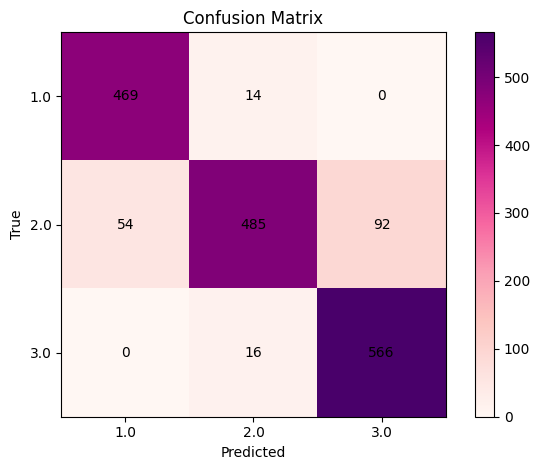

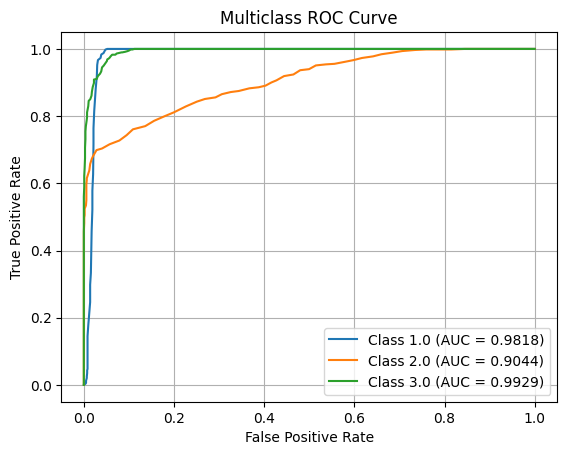

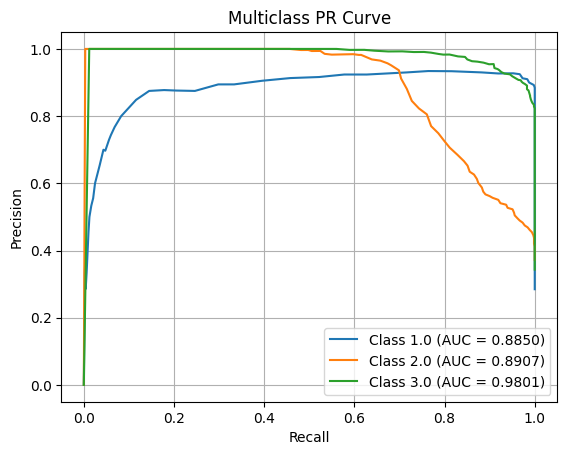

In [42]:
model_lr_trv_Wc = LogisticRegression(
    multiclass_strategy='multinomial',
    iterations=1350,
    l2=best_lambda_lr_Wc,
)
model_lr_trv_Wc.fit(X_train_dt_Wc, y_train_dt_Wc)

y_pred_lr_dt_Wc = model_lr_trv_Wc.predict(X_test_dt_Wc)
y_pred_proba_lr_dt_Wc = model_lr_trv_Wc.predict_proba(X_test_dt_Wc)

# y_scores_dt = model_lr_trv_Wc.predict_proba(X_test_dt_Wc)
# y_pred_dt = (y_scores_dt >= 0.5).astype(int)

print("\nEvaluación en conjunto de test:")

binary_metrics_lr_dt = MulticlassMetrics(y_test_dt_Wc, y_pred_lr_dt_Wc, y_pred_proba_lr_dt_Wc)  # y_scores: probabilidades
binary_metrics_lr_dt.report_metrics(dataset_name="WAR_class_dev", set_type="Test")


In [43]:
lda_dt = LDA()

lda_dt.fit(X_train_dt_Wc, y_train_dt_Wc)

y_pred_LDA_dt = lda_dt.predict(X_test_dt_Wc)
y_pred_prob_LDA_dt = lda_dt.predict_proba(X_test_dt_Wc)

### Métricas de Evaluación para el conjunto de **Test** del set **WAR_class**

| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.9039 |
| Precision |  0.9095 |
| Recall    |  0.9131 |
| F1 Score  |  0.9029 |
| AUC-ROC   |  0.9732 |
| AUC-PR    |  0.8656 |

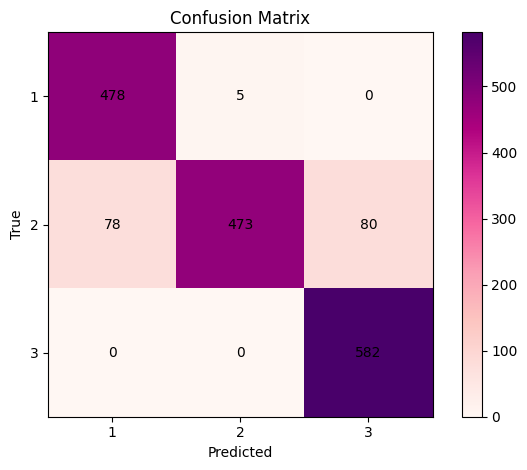

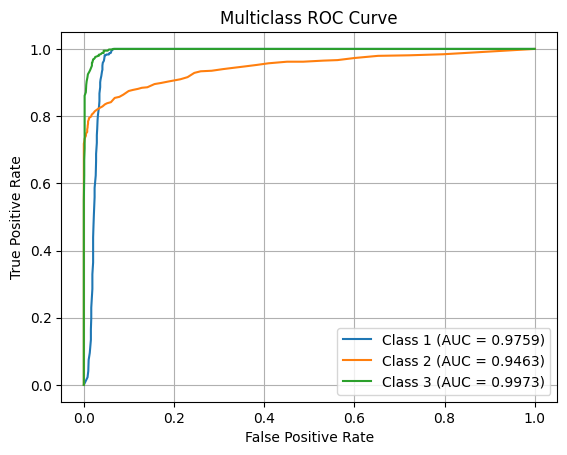

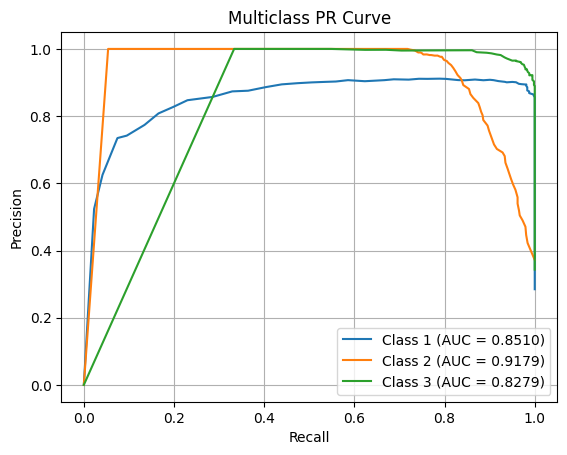

In [44]:
multiclass_metrics_LDA_dt = MulticlassMetrics(y_test_dt_Wc, y_pred_LDA_dt, y_pred_prob_LDA_dt)
multiclass_metrics_LDA_dt.report_metrics(dataset_name="WAR_class", set_type="Test")

In [ ]:
rf_dt = RandomForest()

rf_dt.fit(X_train_dt_Wc, y_train_dt_Wc)

y_pred_rf_dt = rf_dt.predict(X_test_dt_Wc)
y_pred_prob_rf_dt = rf_dt.predict_proba(X_test_dt_Wc)

In [ ]:
multiclass_metrics_rf_dt = MulticlassMetrics(y_test_dt_Wc, y_pred_rf_dt, y_pred_prob_rf_dt)
multiclass_metrics_rf_dt.report_metrics(dataset_name="WAR_class", set_type="Test")